In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

hbdc = pd.read_csv("C:\\Users\\varsh\\Desktop\\DA\\DA_Projects\\Hotel_booking_Project\\Data\\hotel_bookings_cleaned.csv")

# Hotel Booking Demand Analysis

## Exploratory Data Analysis (EDA)

The goal of this analysis is to understand booking patterns, customer behavior, booking trends, seasonality, and reservation outcomes.

In [4]:
hbdc.shape

(87211, 32)

In [5]:
hbdc.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'has_company',
       'has_agent'],
      dtype='str')

In [6]:
hbdc.info()

<class 'pandas.DataFrame'>
RangeIndex: 87211 entries, 0 to 87210
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87211 non-null  str    
 1   is_canceled                     87211 non-null  int64  
 2   lead_time                       87211 non-null  int64  
 3   arrival_date_year               87211 non-null  int64  
 4   arrival_date_month              87211 non-null  str    
 5   arrival_date_week_number        87211 non-null  int64  
 6   arrival_date_day_of_month       87211 non-null  int64  
 7   stays_in_weekend_nights         87211 non-null  int64  
 8   stays_in_week_nights            87211 non-null  int64  
 9   adults                          87211 non-null  int64  
 10  children                        87211 non-null  float64
 11  babies                          87211 non-null  int64  
 12  meal                            87211 non-n

In [7]:
hbdc.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,has_company,has_agent
count,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000,87211.000000
mean,0.275241,79.972217,2016.210398,26.834883,15.815883,1.004667,2.623981,1.879407,0.138927,0.010824,0.038562,0.030409,0.184071,0.268510,0.746454,106.465042,0.084324,0.699029,0.060004,0.860832
std,0.446638,86.060027,0.686031,13.668826,8.835496,1.027403,2.039885,0.621747,0.456310,0.113617,0.192549,0.369384,1.733209,0.710668,10.002084,51.882562,0.281687,0.832091,0.237495,0.346124
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.210000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,510.000000,8.000000,5.000000,1.000000,1.000000


In [8]:
hbdc.describe(include = ["object", "string"])

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,87211,87211,87211,87211,87211,87211,87211,87211,87211,87211,87211,87211
unique,2,12,5,178,8,5,9,11,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2016-02-14
freq,53265,11239,67892,27343,51548,69014,56418,46269,86067,71845,63207,211


### Key Findings

- The dataset contains bookings from both City Hotels and Resort Hotels.
- Customers booked hotels throughout the year across all 12 months.
- Bookings were made from 178 different countries, with Portugal contributing the highest number.
- Most bookings came through Online Travel Agencies (Online TA).
- Room Type A was the most popular room choice.
- Most customers did not pay any deposit while booking.
- Transient customers formed the largest customer category.
- The majority of bookings resulted in a successful check-out.

## 1. Which hotel type receives more bookings?

One of the first things I wanted to understand was which hotel type receives more bookings.

This analysis compares the total number of bookings between Resort Hotels and City Hotels to identify which hotel type is more popular among customers.

In [10]:
hbdc["hotel"].value_counts()

hotel
City Hotel      53265
Resort Hotel    33946
Name: count, dtype: int64

In [11]:
hbdc["hotel"].value_counts(normalize = True) * 100

hotel
City Hotel      61.076011
Resort Hotel    38.923989
Name: proportion, dtype: float64

<Figure size 500x300 with 0 Axes>

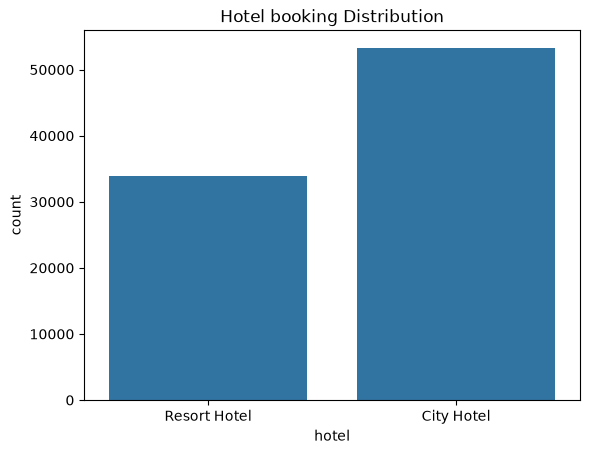

<Figure size 500x300 with 0 Axes>

In [59]:
sns.countplot(data = hbdc, x = "hotel")

plt.title("Hotel booking Distribution")
plt.figure(figsize = (5,3))

### Observation

City Hotels received more bookings than Resort Hotels with 53265 bookings.

This suggests that customers preferred city-based stays over resort stays during the period covered by the dataset.

## 2. How many bookings got canceled?

The most important metric for hotels is the cancellation rate because cancellations directly affect revenue & booking planning.

In [16]:
hbdc["is_canceled"].value_counts(normalize = True) * 100

is_canceled
0    72.475949
1    27.524051
Name: proportion, dtype: float64

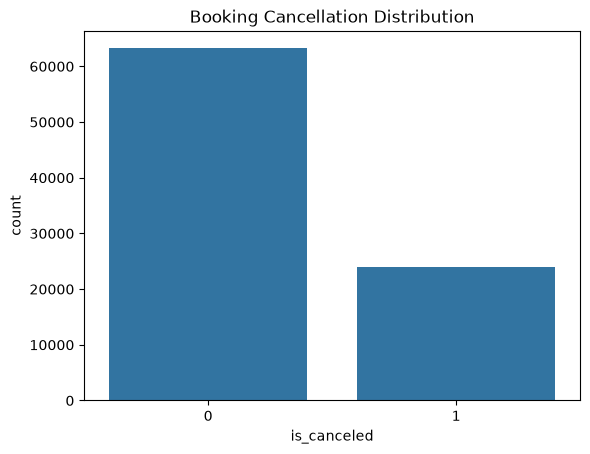

In [58]:
sns.countplot(data = hbdc, x = "is_canceled")

plt.title("Booking Cancellation Distribution")
plt.show()

### Observation

Around 72.5% of the bookings were completed successfully, while about 27.5% were cancelled.

This shows that nearly 1 out of every 4 bookings ended up being cancelled.

## 3. How do booking volumes change throughout the year?

I wanted to understand how bookings are distributed throughout the year.

This analysis helps identify peak and low booking seasons, which can be useful for planning hotel operations and marketing activities.

In [19]:
hbdc["arrival_date_month"].value_counts()

arrival_date_month
August       11239
July         10042
May           8343
April         7899
June          7755
March         7485
October       6921
September     6681
February      6082
December      5110
November      4970
January       4684
Name: count, dtype: int64

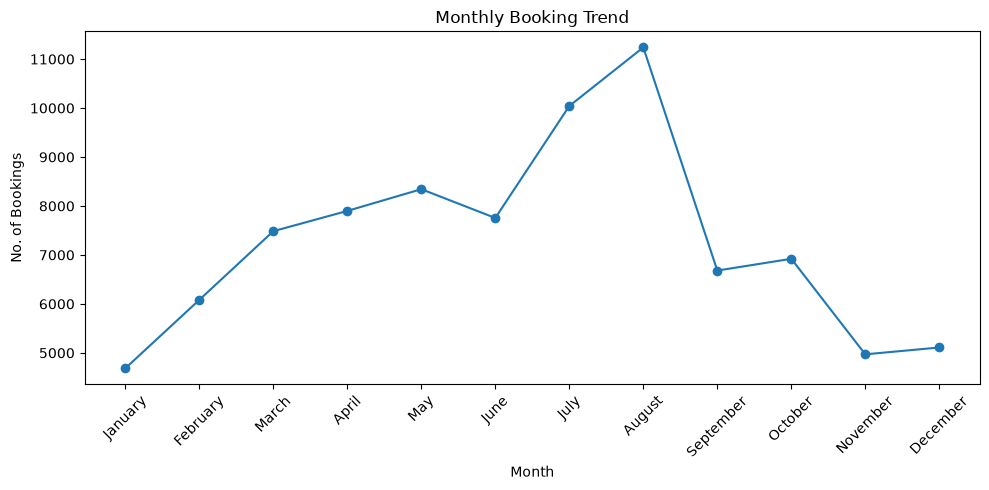

In [57]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

monthly_bookings = (hbdc["arrival_date_month"].value_counts().reindex(month_order))

plt.figure(figsize = (10,5))

plt.plot(monthly_bookings.index, monthly_bookings.values, marker = "o")

plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("No. of Bookings")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Observation

Bookings generally increased from January to August, while August recorded the highest number of bookings.

After August, the number of bookings dropped gradually and remained lower for the rest of the year.

This suggests that hotel demand was highest during the summer months, especially in July and August.

## 4. Which countries generate the most bookings?

I wanted to understand where most hotel guests come from.

Analyzing booking counts by country can help identify the major customer markets and understand which countries contribute the most bookings.

In [29]:
top_countries = hbdc["country"].value_counts().head(10)
top_countries

country
PRT    27343
GBR    10422
FRA     8823
ESP     7243
DEU     5383
ITA     3061
IRL     3015
BEL     2081
BRA     1992
NLD     1910
Name: count, dtype: int64

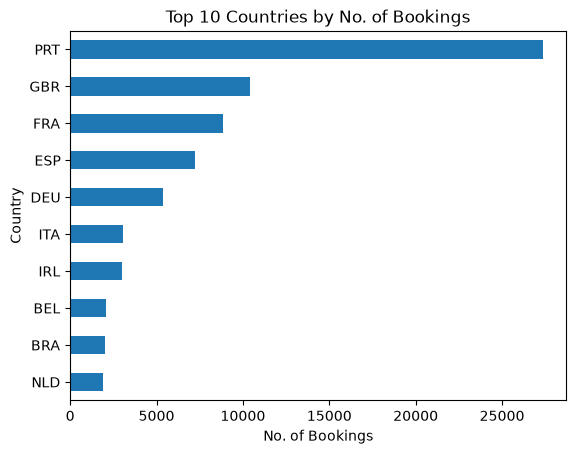

<Figure size 1000x500 with 0 Axes>

In [34]:
top_countries.sort_values().plot(kind = "barh")

plt.xlabel("No. of Bookings")
plt.ylabel("Country")
plt.title("Top 10 Countries by No. of Bookings")
plt.figure(figsize = (10,5))
plt.show()

### Observation

Portugal (PRT) generated the highest number of bookings.

The United Kingdom, France, Spain, and Germany were the next major contributors.

Most of the top booking countries were from Europe, indicating that the hotels mainly attracted European customers.

## 5. How far in advance do customers typically make their bookings?

Lead Time represents the number of days between the booking date and the arrival date.

Analyzing this helps understand customer booking behavior and whether most customers book early or make last-minute reservations.

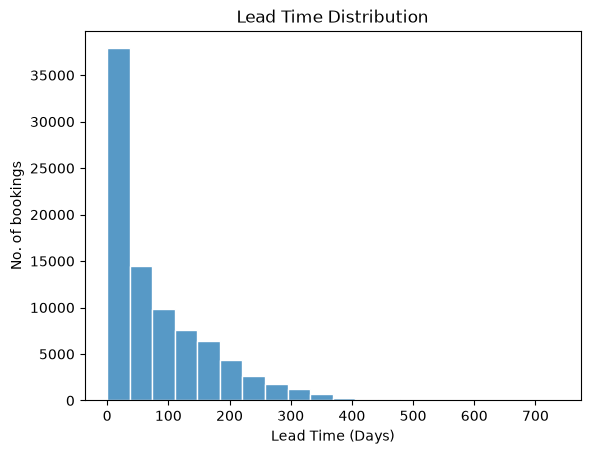

In [56]:
sns.histplot(hbdc["lead_time"], bins = 20, edgecolor = "white")

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("No. of bookings")
plt.show()

### Observation

Most bookings were made with shorter lead times, and the number of bookings gradually decreased as lead time increased.

This suggests that customers generally prefer to book closer to their arrival date, while relatively fewer customers book several months in advance.

## 6. Which customer type contributes the most bookings?

Understanding customer types helps identify the major customer groups and booking patterns within the dataset.

In [46]:
hbdc["customer_type"].value_counts()

customer_type
Transient          71845
Transient-Party    11690
Contract            3135
Group                541
Name: count, dtype: int64

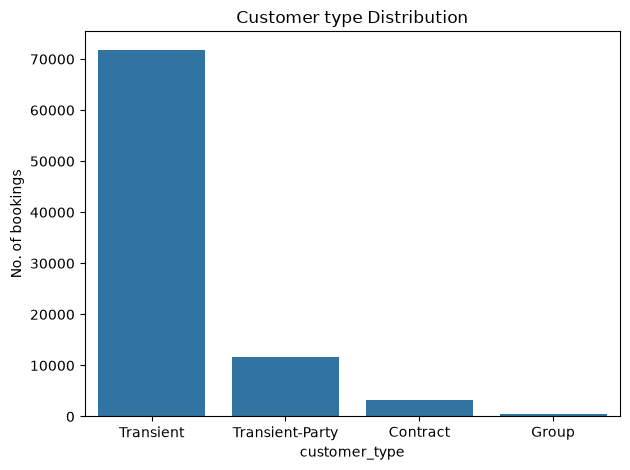

In [55]:
sns.countplot(data = hbdc, x = "customer_type", order = hbdc["customer_type"].value_counts().index)

plt.title("Customer type Distribution")
plt.ylabel("No. of bookings")
plt.tight_layout()
plt.show()

### Observation

Most bookings were made by Transient customers.

Transient-Party customers were the second largest group, while Contract and Group customers contributed only a small portion of total bookings.

This indicates that the majority of hotel bookings came from individual travelers rather than organized groups or contract-based customers.

## 7. How are room prices distributed across bookings?

ADR (Average Daily Rate) represents the average room price paid per booking.

Analyzing ADR helps understand the pricing pattern of hotel bookings and identify whether most bookings fall within a particular price range.

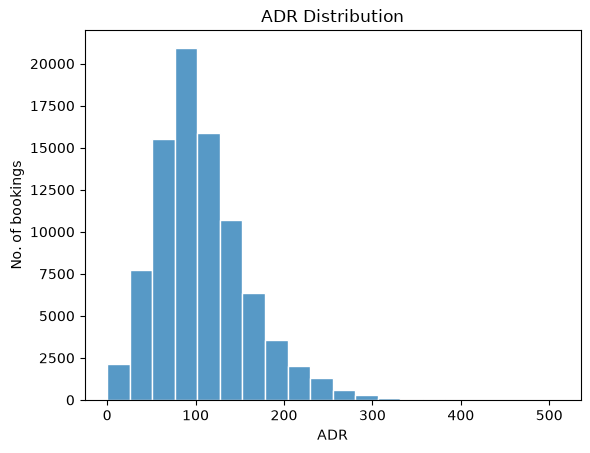

<Figure size 1000x500 with 0 Axes>

In [60]:
sns.histplot(hbdc["adr"], bins = 20, edgecolor = "white")

plt.title("ADR Distribution")
plt.xlabel("ADR")
plt.ylabel("No. of bookings")
plt.figure(figsize = (10,5))
plt.show()

### Observation

Most bookings had an ADR between approximately 50 and 150.

The number of bookings gradually decreased as ADR increased, indicating that higher-priced bookings were less common.

This suggests that most customers preferred rooms in the moderate price range rather than very expensive rooms.

## 8. Which booking channels contribute the most bookings?

Analyzing this helps understand which booking channels bring the highest number of customers to the hotel.

In [61]:
hbdc["market_segment"].value_counts()

market_segment
Online TA        51548
Offline TA/TO    13847
Direct           11780
Groups            4920
Corporate         4196
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64

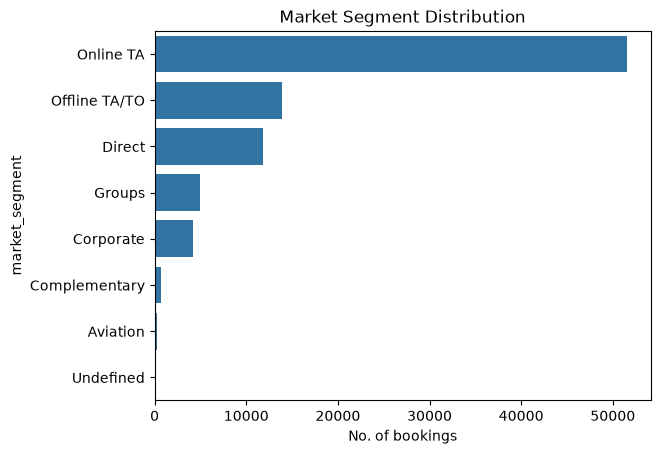

<Figure size 1000x500 with 0 Axes>

In [69]:
sns.countplot(data = hbdc, y = "market_segment", order = hbdc["market_segment"].value_counts().index)

plt.title("Market Segment Distribution")
plt.xlabel("No. of bookings")
plt.figure(figsize = (10,5))
plt.show()

### Observation

Most bookings were made through Online Travel Agencies (Online TA).

Offline TA/TO and Direct bookings were the next major booking channels, while the remaining market segments contributed only a small number of bookings.

This shows that online booking platforms played a major role in bringing customers to the hotels.

## 9. What is the final status of hotel bookings?

Reservation Status shows whether a booking was completed, cancelled, or marked as a no-show.

Analyzing this helps understand the overall outcome of hotel bookings.

In [70]:
hbdc["reservation_status"].value_counts()

reservation_status
Check-Out    63207
Canceled     22991
No-Show       1013
Name: count, dtype: int64

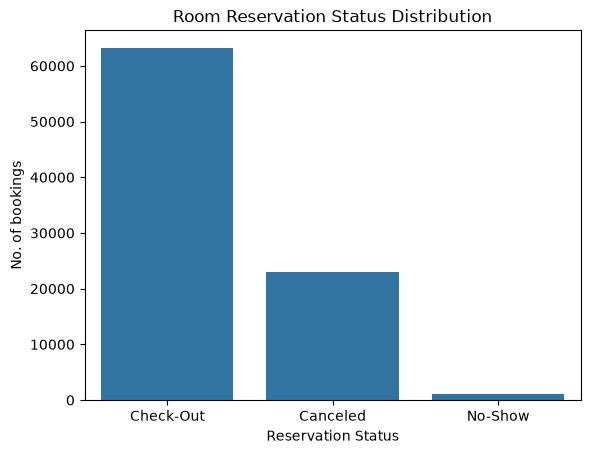

<Figure size 800x500 with 0 Axes>

In [73]:
sns.countplot(data = hbdc, x = "reservation_status", order = hbdc["reservation_status"].value_counts().index)

plt.title("Room Reservation Status Distribution")
plt.xlabel("Reservation Status")
plt.ylabel("No. of bookings")
plt.figure(figsize = (8,5))
plt.show()

### Observation

Most bookings ended with a successful check-out.

Some bookings were cancelled, while only a very small number of customers did not show up after making a booking.

This indicates that most customers completed their stay, although cancellations happened.

# Key Findings from EDA

- City Hotels received more bookings than Resort Hotels.
- Around 72% of bookings were completed, while about 28% were cancelled.
- Booking demand increased during the year and peaked in July and August.
- Portugal generated the highest number of bookings.
- Most customers booked within a shorter lead time.
- Transient customers are accommodated for the majority of bookings.
- Most room rates (ADR) were allotted in the moderate price range.
- Online Travel Agencies (Online TA) were the largest booking channel.
- Most reservations ended with a successful check-out.

### Conclusion

The analysis revealed clear patterns in customer behavior, booking trends, booking channels, and reservation outcomes. These insights will be further explored through SQL analysis and visualized in the dashboard phase of the project.